In [ ]:
# Clean up the accidentally created files from the previous run
!rm -f /content/=*

# Install the dependencies cleanly in a single line
!pip install "torch>=2.1.0" "torchvision>=0.16.0" "segmentation-models-pytorch>=0.3.3" "albumentations>=1.4.0" "opencv-python-headless>=4.9.0" "numpy>=1.26.0" "Pillow>=10.0.0" "tqdm>=4.66.0" "matplotlib>=3.8.0" "scikit-learn>=1.4.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.2 MB/s eta 0:00:00


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cpu
CUDA available: False


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/SIH26143/oil_spill_segmentation",
    exist_ok=True
)

In [ ]:
!ls -lh /content/drive/MyDrive/SIH26143/oil_spill_segmentation/

total 1.1G
drwx------ 2 root root 4.0K Sep 27 14:13 data
-rw------- 1 root root 1.1G Sep 27 13:53 images.zip
-rw------- 1 root root  27M Sep 27 14:06 masks.zip
drwx------ 2 root root 4.0K Sep 27 16:27 models


In [ ]:
!mkdir -p /content/drive/MyDrive/SIH26143/oil_spill_segmentation/data

In [ ]:
!unzip -q \
"/content/drive/MyDrive/SIH26143/oil_spill_segmentation/images.zip" \
-d "/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data"

replace /content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/._images? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!unzip -q \
"/content/drive/MyDrive/SIH26143/oil_spill_segmentation/masks.zip" \
-d "/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data"

replace /content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/._masks? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!find "/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data" \
-maxdepth 3 -type d
!find "/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data" \
-maxdepth 3 -type f | head -30

/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/masks
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/masks/train
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/masks/val
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/images
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/images/train
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/images/val
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/images
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/images/train
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/images/val
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/masks
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/__MACOSX/masks/train
/content/drive/MyDrive/SIH26143/oil_spill_segmentation/dat

In [ ]:
!pip install -q segmentation-models-pytorch

In [ ]:
!pip install -q rasterio opencv-python matplotlib scikit-learn

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
from collections import Counter

DATA_ROOT = Path(
    "/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data"
)

IMAGE_ROOT = DATA_ROOT / "images"
MASK_ROOT = DATA_ROOT / "masks"

# --------------------------------------------------
# 1. Count files
# --------------------------------------------------

for split in ["train", "val"]:
    images = list((IMAGE_ROOT / split).glob("*.png"))
    masks = list((MASK_ROOT / split).glob("*.png"))

    print(f"\n===== {split.upper()} =====")
    print("Images:", len(images))
    print("Masks :", len(masks))

# --------------------------------------------------
# 2. Check image-mask matching
# --------------------------------------------------

for split in ["train", "val"]:
    image_stems = {
        p.stem for p in (IMAGE_ROOT / split).glob("*.png")
    }

    mask_stems = {
        p.stem for p in (MASK_ROOT / split).glob("*.png")
    }

    missing_masks = image_stems - mask_stems
    missing_images = mask_stems - image_stems

    print(f"\n===== MATCHING: {split.upper()} =====")
    print("Images without masks:", len(missing_masks))
    print("Masks without images:", len(missing_images))

    if missing_masks:
        print("Example missing masks:", list(missing_masks)[:10])

    if missing_images:
        print("Example missing images:", list(missing_images)[:10])

# --------------------------------------------------
# 3. Inspect representative images
# --------------------------------------------------

def inspect_image(path):
    img = Image.open(path)
    arr = np.array(img)

    print(f"\nFile: {path.name}")
    print("PIL mode :", img.mode)
    print("Shape    :", arr.shape)
    print("Dtype    :", arr.dtype)
    print("Min      :", arr.min())
    print("Max      :", arr.max())
    print("Mean     :", arr.mean())
    print("Std      :", arr.std())

# Pick one Sentinel and one PALSAR image
train_images = list((IMAGE_ROOT / "train").glob("*.png"))

sentinel = next(
    (p for p in train_images if p.name.startswith("sentinel_")),
    None
)

palsar = next(
    (p for p in train_images if p.name.startswith("palsar_")),
    None
)

print("\n===== SAMPLE IMAGES =====")

if sentinel:
    inspect_image(sentinel)

if palsar:
    inspect_image(palsar)

# --------------------------------------------------
# 4. Inspect corresponding masks
# --------------------------------------------------

print("\n===== SAMPLE MASKS =====")

for image_path in [sentinel, palsar]:

    if image_path is None:
        continue

    mask_path = MASK_ROOT / "train" / image_path.name

    print(f"\nImage: {image_path.name}")
    print("Mask :", mask_path)

    if mask_path.exists():

        mask = Image.open(mask_path)
        mask_arr = np.array(mask)

        print("Mask mode :", mask.mode)
        print("Mask shape:", mask_arr.shape)
        print("Mask dtype:", mask_arr.dtype)

        unique, counts = np.unique(
            mask_arr,
            return_counts=True
        )

        print("Unique mask values:", unique)

        print("Pixel counts:")
        for value, count in zip(unique, counts):
            print(f"  {value}: {count}")

    else:
        print("MASK NOT FOUND")


===== TRAIN =====
Images: 6455
Masks : 6455

===== VAL =====
Images: 1615
Masks : 1615

===== MATCHING: TRAIN =====
Images without masks: 0
Masks without images: 0

===== MATCHING: VAL =====
Images without masks: 0
Masks without images: 0

===== SAMPLE IMAGES =====

File: sentinel_3118.png
PIL mode : RGB
Shape    : (256, 256, 3)
Dtype    : uint8
Min      : 4
Max      : 133
Mean     : 75.25148010253906
Std      : 21.172361602323686

File: palsar_42.png
PIL mode : RGB
Shape    : (256, 256, 3)
Dtype    : uint8
Min      : 0
Max      : 255
Mean     : 101.16990661621094
Std      : 49.88229295225295

===== SAMPLE MASKS =====

Image: sentinel_3118.png
Mask : /content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/masks/train/sentinel_3118.png
Mask mode : L
Mask shape: (256, 256)
Mask dtype: uint8
Unique mask values: [  0 255]
Pixel counts:
  0: 54266
  255: 11270

Image: palsar_42.png
Mask : /content/drive/MyDrive/SIH26143/oil_spill_segmentation/data/masks/train/palsar_42.png
Mask mode : 

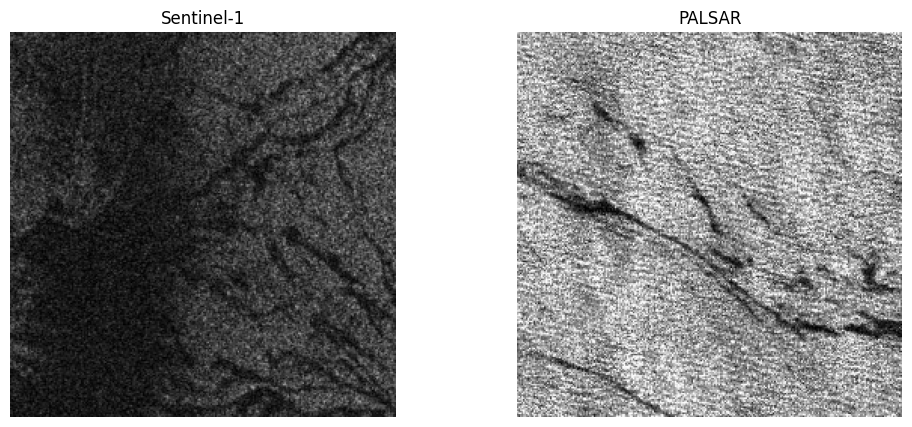

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sentinel_img = np.array(
    Image.open(IMAGE_ROOT / "train" / "sentinel_984.png")
)

palsar_img = np.array(
    Image.open(IMAGE_ROOT / "train" / "palsar_2644.png")
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sentinel_img)
plt.title("Sentinel-1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(palsar_img)
plt.title("PALSAR")
plt.axis("off")

plt.show()

In [ ]:
from PIL import Image
import numpy as np
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/SIH26143/oil_spill_segmentation/data")
MASK_ROOT = DATA_ROOT / "masks"

for name in ["sentinel_984.png", "palsar_2644.png"]:

    path = MASK_ROOT / "train" / name
    mask = np.array(Image.open(path))

    print("\n==============================")
    print(name)

    print("==============================")

    print("Shape:", mask.shape)
    print("Dtype:", mask.dtype)

    if mask.ndim == 3:
        print("R == G:", np.array_equal(mask[:,:,0], mask[:,:,1]))
        print("G == B:", np.array_equal(mask[:,:,1], mask[:,:,2]))
        print("R == B:", np.array_equal(mask[:,:,0], mask[:,:,2]))

        print(
            "Different RGB pixels:",
            np.any(mask != mask[:,:,0:1], axis=2).sum()
        )

    # Convert to grayscale
    gray = np.array(Image.open(path).convert("L"))

    unique = np.unique(gray)

    print("\nGrayscale unique values:")
    print(unique[:100])

    print("\nNumber of unique values:", len(unique))

    print("Pixels == 0:", np.sum(gray == 0))
    print("Pixels == 255:", np.sum(gray == 255))

    # Tentative binary conversion
    binary = (gray > 127).astype(np.uint8)

    print("\nAfter thresholding > 127:")
    print("Background:", np.sum(binary == 0))
    print("Oil:", np.sum(binary == 1))


sentinel_984.png
Shape: (256, 256, 3)
Dtype: uint8
R == G: True
G == B: True
R == B: True
Different RGB pixels: 0

Grayscale unique values:
[  0   1   2   3   4   5   7   8   9  10  11  12  13  14  15  17  18  19
  20  21  23  24  25  26  28  30  31  32  33  34  35  36  37  39  41  42
  43  44  45  46  47  49  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  66  67  70  71  72  74  75  76  77  78  79  81  82  84  85
  86  87  88  89  91  92  94  95  96  97  98 101 102 103 104 105 106 108
 109 110 111 114 115 116 117 118 119 120]

Number of unique values: 209
Pixels == 0: 15132
Pixels == 255: 48659

After thresholding > 127:
Background: 16025
Oil: 49511

palsar_2644.png
Shape: (256, 256)
Dtype: uint8

Grayscale unique values:
[  0 255]

Number of unique values: 2
Pixels == 0: 59256
Pixels == 255: 6280

After thresholding > 127:
Background: 59256
Oil: 6280


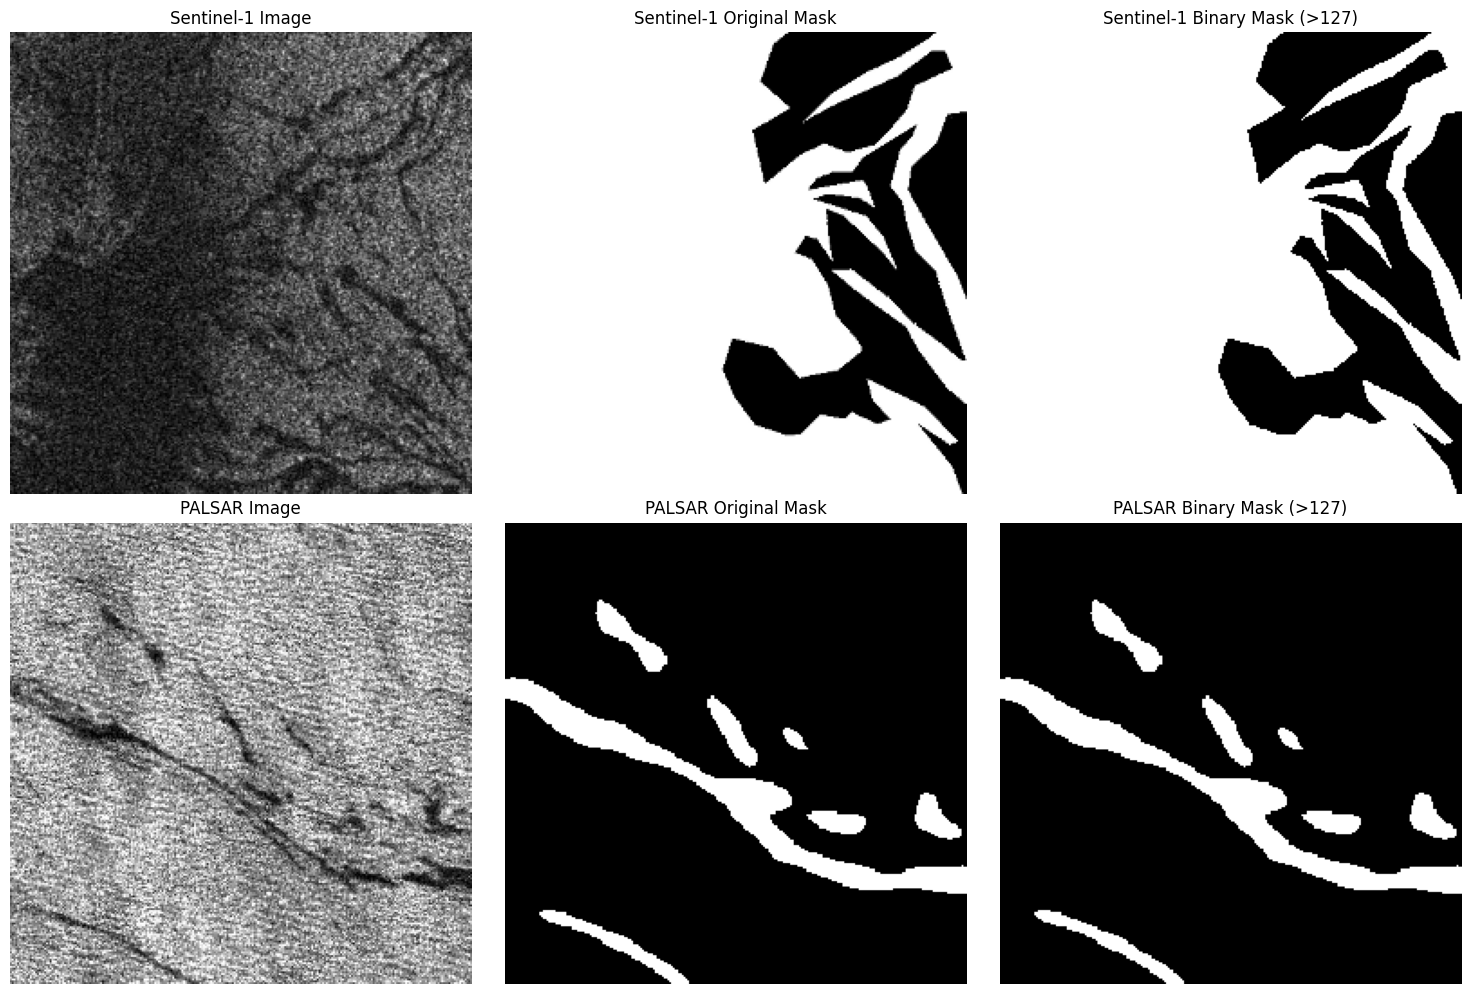

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

samples = [
    ("sentinel_984.png", "Sentinel-1"),
    ("palsar_2644.png", "PALSAR")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (filename, title) in enumerate(samples):

    image_path = DATA_ROOT / "images" / "train" / filename
    mask_path = DATA_ROOT / "masks" / "train" / filename

    image = np.array(Image.open(image_path).convert("L"))
    mask = np.array(Image.open(mask_path).convert("L"))

    binary = (mask > 127).astype(np.uint8)

    # Original SAR image
    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title(f"{title} Image")
    axes[row, 0].axis("off")

    # Original mask
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title(f"{title} Original Mask")
    axes[row, 1].axis("off")

    # Binary mask
    axes[row, 2].imshow(binary, cmap="gray")
    axes[row, 2].set_title(f"{title} Binary Mask (>127)")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q segmentation-models-pytorch
import torch
import segmentation_models_pytorch as smp

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset


class OilSpillDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)

        self.images = sorted(self.image_dir.glob("*.png"))

        print(f"Found {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]
        mask_path = self.mask_dir / image_path.name

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Load mask as grayscale
        mask = Image.open(mask_path).convert("L")

        # Convert to numpy
        image = np.array(image)
        mask = np.array(mask)

        # Normalize image to [0, 1]
        image = image.astype(np.float32) / 255.0

        # Convert mask to binary
        mask = (mask > 127).astype(np.float32)

        # HWC → CHW
        image = np.transpose(image, (2, 0, 1))

        # Convert to tensors
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        # Add channel dimension to mask
        mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
TRAIN_IMAGE_DIR = DATA_ROOT / "images" / "train"
TRAIN_MASK_DIR  = DATA_ROOT / "masks" / "train"

VAL_IMAGE_DIR = DATA_ROOT / "images" / "val"
VAL_MASK_DIR  = DATA_ROOT / "masks" / "val"


train_dataset = OilSpillDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR
)

val_dataset = OilSpillDataset(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR
)

Found 6455 images
Found 1615 images


In [ ]:
image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Image min:", image.min().item())
print("Image max:", image.max().item())

print()

print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Mask unique values:", torch.unique(mask))

Image shape: torch.Size([3, 256, 256])
Image dtype: torch.float32
Image min: 0.0
Image max: 1.0

Mask shape: torch.Size([1, 256, 256])
Mask dtype: torch.float32
Mask unique values: tensor([0., 1.])


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, masks = next(iter(train_loader))

print("Batch images:", images.shape)
print("Batch masks :", masks.shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch images: torch.Size([2, 3, 256, 256])
Batch masks : torch.Size([2, 1, 256, 256])


In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

print("Device:", device)
print("Model created successfully")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cpu
Model created successfully


In [ ]:
images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])


In [ ]:
import torch
import torch.nn as nn


class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()


def combined_loss(logits, targets):

    bce = bce_loss(logits, targets)
    dice = dice_loss(logits, targets)

    return bce + dice

In [ ]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

loss = combined_loss(outputs, masks)

print("Output shape:", outputs.shape)
print("Mask shape  :", masks.shape)
print("Loss        :", loss.item())

Output shape: torch.Size([2, 1, 256, 256])
Mask shape  : torch.Size([2, 1, 256, 256])
Loss        : 1.2635185718536377


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scaler = torch.amp.GradScaler("cuda")
import torch
from tqdm.auto import tqdm

EPOCHS = 2

for epoch in range(EPOCHS):

    # =========================
    # TRAIN
    # =========================
    model.train()

    train_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"
    )

    for images, masks in progress:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = combined_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader)


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        progress = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"
        )

        for images, masks in progress:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = combined_loss(outputs, masks)

            val_loss += loss.item()

            progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss /= len(val_loader)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}\n"
    )

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(val_loader))

images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)

probs = torch.sigmoid(outputs)
preds = (probs > 0.5).float()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i in range(2):

    # Original image
    axes[i, 0].imshow(
        images[i].permute(1, 2, 0)
    )
    axes[i, 0].set_title("SAR Image")
    axes[i, 0].axis("off")

    # Ground truth
    axes[i, 1].imshow(
        masks[i, 0],
        cmap="gray"
    )
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(
        preds[i, 0].cpu(),
        cmap="gray"
    )
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def calculate_metrics(logits, masks, threshold=0.5):

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    smooth = 1e-6

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

    dice = (
        (2 * intersection + smooth) /
        (union + smooth)
    )

    total_union = (
        preds.sum(dim=(1, 2, 3))
        + masks.sum(dim=(1, 2, 3))
        - intersection
    )

    iou = (
        (intersection + smooth) /
        (total_union + smooth)
    )

    return dice.mean().item(), iou.mean().item()
model.eval()

total_dice = 0
total_iou = 0
num_batches = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        dice, iou = calculate_metrics(outputs, masks)

        total_dice += dice
        total_iou += iou
        num_batches += 1

avg_dice = total_dice / num_batches
avg_iou = total_iou / num_batches

print(f"Validation Dice: {avg_dice:.4f}")
print(f"Validation IoU : {avg_iou:.4f}")

/tmp/ipykernel_12820/2062528112.py:41: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast("cuda"):


Validation Dice: 0.0433
Validation IoU : 0.0433


In [ ]:
import torch
from tqdm.auto import tqdm

EPOCHS = 10

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}

for epoch in range(EPOCHS):

    # ==========================================
    # TRAIN
    # ==========================================
    model.train()

    running_train_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"
    )

    for images, masks in progress:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = combined_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_train_loss / len(train_loader)


    # ==========================================
    # VALIDATION
    # ==========================================
    model.eval()

    running_val_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    num_batches = 0

    with torch.no_grad():

        progress = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"
        )

        for images, masks in progress:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = combined_loss(outputs, masks)

            dice, iou = calculate_metrics(outputs, masks)

            running_val_loss += loss.item()
            running_dice += dice
            running_iou += iou

            num_batches += 1

    val_loss = running_val_loss / num_batches
    val_dice = running_dice / num_batches
    val_iou = running_iou / num_batches


    # ==========================================
    # SAVE HISTORY
    # ==========================================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)


    # ==========================================
    # SAVE BEST MODEL
    # ==========================================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou
        }, "best_oil_spill_deeplabv3_resnet34.pth")

        saved = " ⭐ BEST MODEL"

    else:
        saved = ""


    print(
        f"\nEpoch {epoch+1}/{EPOCHS}  "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Dice: {val_dice:.4f} "
        f"| IoU: {val_iou:.4f}"
        f"{saved}\n"
    )

Epoch 1/10 [Train]:   0%|          | 0/3227 [00:00<?, ?it/s]

/tmp/ipykernel_12820/557518758.py:36: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast("cuda"):


In [ ]:
checkpoint = torch.load(
    "best_oil_spill_deeplabv3_resnet34.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

print("Best epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])
print("Best Dice:", checkpoint["val_dice"])
print("Best IoU:", checkpoint["val_iou"])

In [ ]:
from pathlib import Path
import shutil

DRIVE_MODEL_DIR = Path(
    "/content/drive/MyDrive/SIH26143/oil_spill_segmentation/models"
)

DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

src = Path("best_oil_spill_deeplabv3_resnet34.pth")
dst = DRIVE_MODEL_DIR / src.name

shutil.copy2(src, dst)

print("Saved permanently to:")
print(dst)